# 09 – Final Classification Comparison

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from classification_utils import load_data, prepare_target, make_split, make_preprocessor, make_pipeline

df, feature_cols = prepare_target(load_data())
X_train, X_test, y_train, y_test, le = make_split(df, feature_cols)
preprocessor = make_preprocessor(X_train)

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(kernel="rbf", random_state=42)
}

results=[]
cms={}

for name, model in models.items():
    pipe=make_pipeline(model, preprocessor)
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred,average="weighted",zero_division=0),
        "Recall":recall_score(y_test,pred,average="weighted",zero_division=0),
        "Weighted F1":f1_score(y_test,pred,average="weighted",zero_division=0)
    })
    cms[name]=confusion_matrix(y_test,pred)

results_df=pd.DataFrame(results).sort_values("Weighted F1",ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "Accuracy":"{:.4f}","Precision":"{:.4f}","Recall":"{:.4f}","Weighted F1":"{:.4f}"
}))

,Model,Accuracy,Precision,Recall,Weighted F1
0,SVC,0.7404,0.7506,0.7404,0.7407
1,K-Nearest Neighbors,0.7352,0.7448,0.7352,0.7314
2,Decision Tree,0.6967,0.7051,0.6967,0.6986
3,Logistic Regression,0.6787,0.6853,0.6787,0.6804
4,Gaussian Naive Bayes,0.5913,0.6499,0.5913,0.5706


## Combined Confusion Matrices

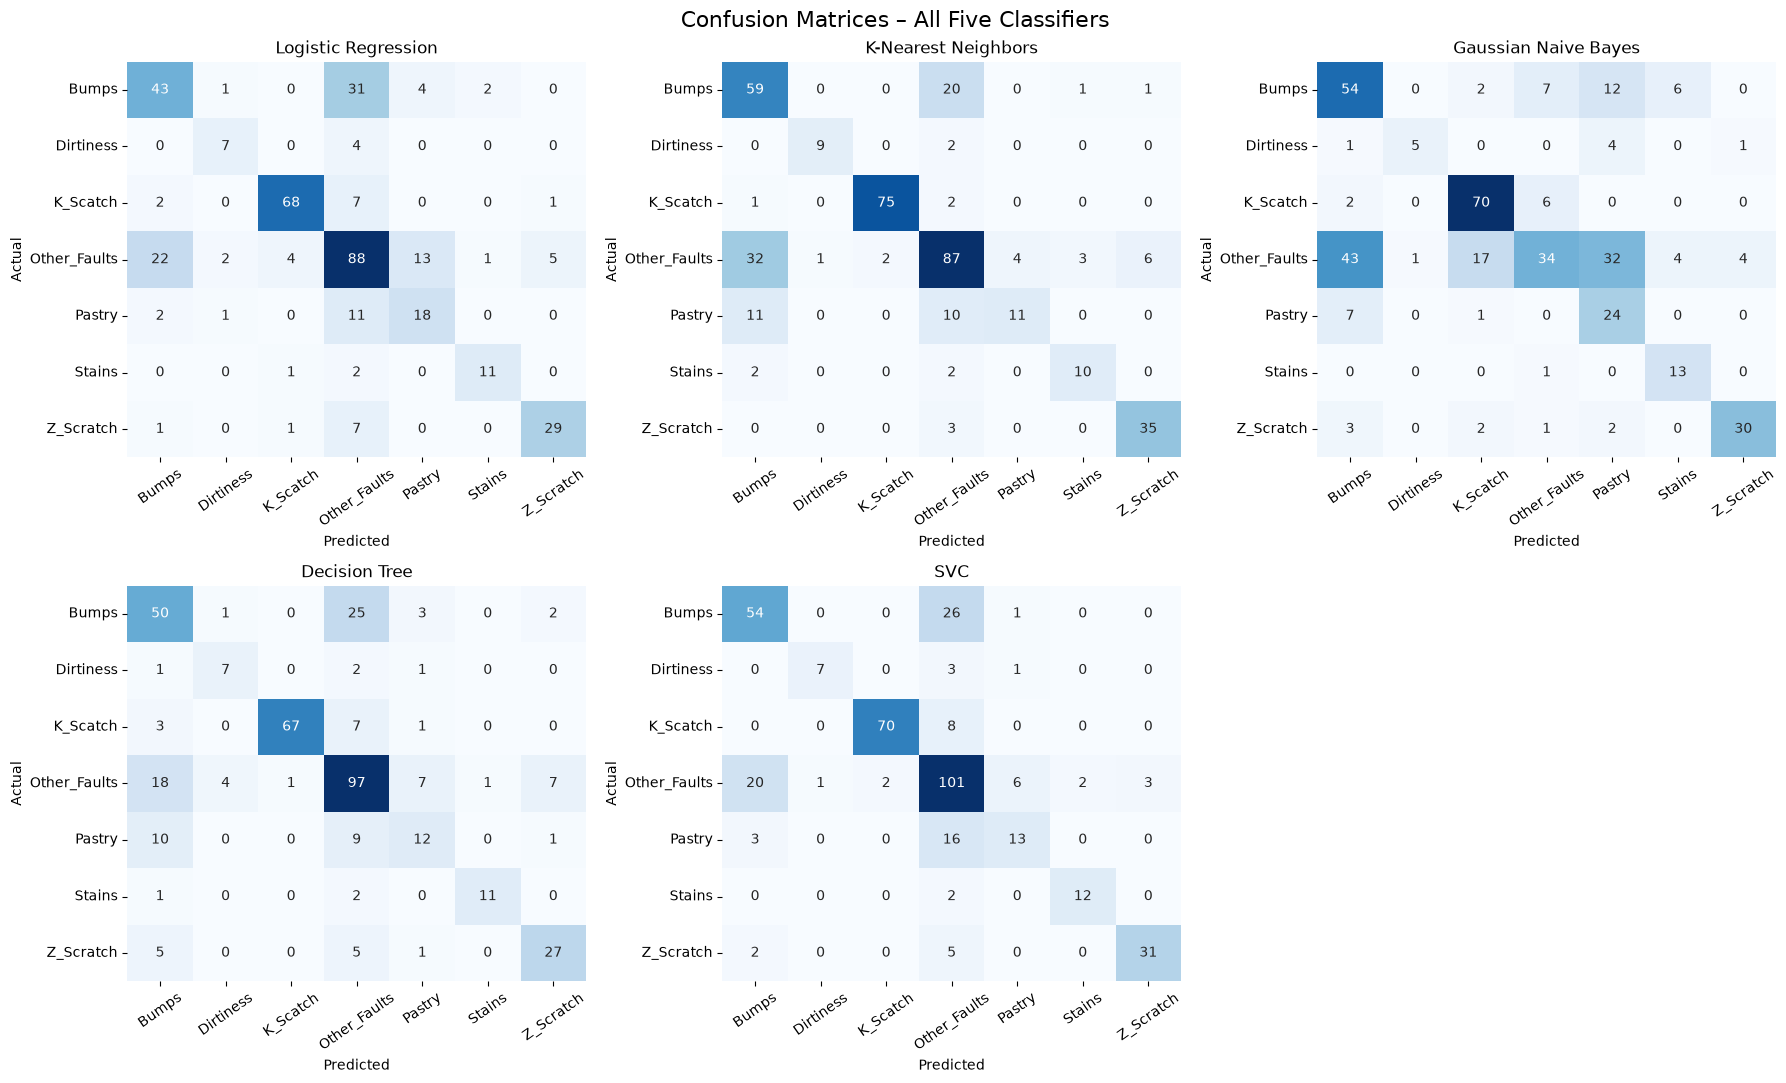

In [3]:
fig, axes = plt.subplots(2,3,figsize=(18,11))
axes=axes.flatten()

for ax,(name,cm) in zip(axes,cms.items()):
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False,
                xticklabels=le.classes_,yticklabels=le.classes_,ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x",rotation=35)

axes[-1].axis("off")
plt.suptitle("Confusion Matrices – All Five Classifiers",fontsize=16)
plt.tight_layout()
plt.show()

### Final Observation

All five classifiers are evaluated on the identical stratified test split. The comparison table provides Accuracy, weighted Precision, weighted Recall and weighted F1, while the confusion matrices show the class-level error patterns. The model results should be discussed using these measured values rather than accuracy alone.